# Análise NovaShop — Peers Group Case

**Objetivo:** Identificar padrões e anomalias nas bases de dados da NovaShop para diagnosticar a causa raiz do alto volume de cancelamentos, devoluções e tickets de suporte.

**Bases utilizadas:** `clientes`, `pedidos`, `produtos`, `itens_pedido`, `avaliacoes`, `tickets_suporte`

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED', '#0891B2']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams['figure.dpi'] = 120

DATA_DIR         = '../data'
OUTPUT_GRAFICOS  = '../output/graficos'
OUTPUT_TRATADOS  = '../output/dados_tratados'
OUTPUT_AGREGADOS = '../output/dados_agregados'

for d in [OUTPUT_GRAFICOS, OUTPUT_TRATADOS, OUTPUT_AGREGADOS]:
    os.makedirs(d, exist_ok=True)
print('Setup concluído.')

Setup concluído.


## 1. Carregamento dos Dados

In [2]:
clientes  = pd.read_csv(f'{DATA_DIR}/clientes.csv')
pedidos   = pd.read_csv(f'{DATA_DIR}/pedidos.csv', parse_dates=['data_pedido'])
produtos  = pd.read_csv(f'{DATA_DIR}/produtos.csv')
itens     = pd.read_csv(f'{DATA_DIR}/itens_pedido.csv')
avaliacoes = pd.read_csv(f'{DATA_DIR}/avaliacoes.csv', parse_dates=['data_avaliacao'])
tickets   = pd.read_csv(f'{DATA_DIR}/tickets_suporte.csv', parse_dates=['data_abertura', 'data_resolucao'])

print(f'clientes:   {clientes.shape}')
print(f'pedidos:    {pedidos.shape}')
print(f'produtos:   {produtos.shape}')
print(f'itens:      {itens.shape}')
print(f'avaliacoes: {avaliacoes.shape}')
print(f'tickets:    {tickets.shape}')

clientes:   (3000, 8)
pedidos:    (15000, 7)
produtos:   (200, 7)
itens:      (36740, 6)
avaliacoes: (8000, 7)
tickets:    (4000, 7)


---
## Pergunta 6 — Qualidade dos Dados: Inconsistências e Tratamento

> *"Identifique e trate inconsistências na base (campos nulos, valores fora do padrão). Documente o que foi encontrado e como você tratou cada caso."*

Realizamos o diagnóstico antes das análises para garantir que todas as métricas sejam calculadas sobre dados tratados.

### 6.1 Campos Nulos

In [3]:
frames = {
    'clientes': clientes, 'pedidos': pedidos, 'produtos': produtos,
    'itens': itens, 'avaliacoes': avaliacoes, 'tickets': tickets
}

print('=== Campos com valores nulos ===')
for nome, df in frames.items():
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos):
        for col, n in nulos.items():
            pct = n / len(df) * 100
            print(f'  [{nome}] {col}: {n} nulos ({pct:.1f}%)')
    else:
        print(f'  [{nome}] sem nulos')

=== Campos com valores nulos ===
  [clientes] sem nulos
  [pedidos] valor_total: 79 nulos (0.5%)
  [produtos] sem nulos
  [itens] desconto_aplicado: 301 nulos (0.8%)
  [avaliacoes] comentario: 1679 nulos (21.0%)
  [tickets] data_resolucao: 1653 nulos (41.3%)


**Achados:**
- `pedidos.valor_total`: 79 nulos (0,5%) — pedidos sem valor registrado
- `itens.desconto_aplicado`: 301 nulos (0,8%) — desconto não informado nos itens
- `avaliacoes.comentario`: 1.679 nulos (21%) — campo opcional, comportamento esperado
- `tickets.data_resolucao`: 1.653 nulos (41,3%) — tickets ainda abertos ou escalados

### 6.2 Integridade Referencial

In [4]:
ped_ids  = set(pedidos['id'])
cli_ids  = set(clientes['id'])
prod_ids = set(produtos['id'])

checks = {
    'Pedidos com cliente inexistente':   (~pedidos['cliente_id'].isin(cli_ids)).sum(),
    'Itens com pedido inexistente':      (~itens['pedido_id'].isin(ped_ids)).sum(),
    'Itens com produto inexistente':     (~itens['produto_id'].isin(prod_ids)).sum(),
    'Tickets com pedido inexistente':    (~tickets['pedido_id'].isin(ped_ids)).sum(),
    'Avaliações com pedido inexistente': (~avaliacoes['pedido_id'].isin(ped_ids)).sum(),
}

for desc, n in checks.items():
    status = '✓ OK' if n == 0 else f'⚠ {n} registros'
    print(f'  {desc}: {status}')

  Pedidos com cliente inexistente: ✓ OK
  Itens com pedido inexistente: ✓ OK
  Itens com produto inexistente: ✓ OK
  Tickets com pedido inexistente: ✓ OK
  Avaliações com pedido inexistente: ✓ OK


### 6.3 Divergência entre `valor_total` e Soma dos Itens

Esta é a anomalia mais crítica encontrada na base.

In [5]:
itens_calc = itens.copy()
itens_calc['desconto_aplicado'] = itens_calc['desconto_aplicado'].fillna(0)
itens_calc['valor_item'] = (
    itens_calc['preco_praticado']
    * itens_calc['quantidade']
    * (1 - itens_calc['desconto_aplicado'])
)
soma_itens = itens_calc.groupby('pedido_id')['valor_item'].sum().reset_index()
soma_itens.columns = ['id', 'soma_calculada']

check = pedidos.dropna(subset=['valor_total']).merge(soma_itens, on='id', how='left')
check['divergencia'] = abs(check['valor_total'] - check['soma_calculada'])
check['divergencia_pct'] = check['divergencia'] / check['soma_calculada'] * 100

print('Divergência absoluta (R$) entre valor_total e soma dos itens:')
print(check['divergencia'].describe().to_frame().T.to_string(index=False))
print(f'\nPedidos com divergência > R$10: {(check["divergencia"] > 10).sum()} de {len(check)}')
print(f'\nInterpretação: valor_total em pedidos foi registrado de forma independente'
      f'\ndos itens (pode incluir frete, descontos de cupom no nível do pedido etc.).'
      f'\nNão é possível reconciliar sem informações adicionais.'
      f'\n→ Usaremos valor_total para análises de receita por pedido e'
      f'\n  preco_praticado × quantidade para análises por produto.')

Divergência absoluta (R$) entre valor_total e soma dos itens:
    count     mean      std  min      25%      50%       75%       max
14,921.00 9,420.76 8,265.55 0.28 2,937.54 7,291.09 13,480.97 61,603.62

Pedidos com divergência > R$10: 14903 de 14921

Interpretação: valor_total em pedidos foi registrado de forma independente
dos itens (pode incluir frete, descontos de cupom no nível do pedido etc.).
Não é possível reconciliar sem informações adicionais.
→ Usaremos valor_total para análises de receita por pedido e
  preco_praticado × quantidade para análises por produto.


### 6.4 Tratamento Aplicado

In [6]:
# --- pedidos: remover registros sem valor_total ---
n_antes = len(pedidos)
pedidos_limpos = pedidos.dropna(subset=['valor_total']).copy()
n_depois = len(pedidos_limpos)
print(f'pedidos: removidos {n_antes - n_depois} registros sem valor_total ({n_antes} → {n_depois})')

# --- itens: preencher desconto nulo com 0 (sem desconto) ---
n_nulos_desc = itens['desconto_aplicado'].isnull().sum()
itens_limpos = itens.copy()
itens_limpos['desconto_aplicado'] = itens_limpos['desconto_aplicado'].fillna(0)
print(f'itens: {n_nulos_desc} nulos em desconto_aplicado preenchidos com 0')

# --- avaliacoes: comentario nulo é campo opcional — manter como está ---
print('avaliacoes: comentario nulo mantido (campo opcional, sem impacto nas métricas)')

# --- tickets: data_resolucao nula indica ticket ainda aberto/escalado ---
n_sem_resolucao = tickets['data_resolucao'].isnull().sum()
print(f'tickets: {n_sem_resolucao} registros sem data_resolucao (tickets abertos/escalados — mantidos)')

# --- calcular valor_item nos itens ---
itens_limpos['valor_item'] = (
    itens_limpos['preco_praticado']
    * itens_limpos['quantidade']
    * (1 - itens_limpos['desconto_aplicado'])
)

print('\n→ Bases tratadas: pedidos_limpos, itens_limpos')

pedidos: removidos 79 registros sem valor_total (15000 → 14921)
itens: 301 nulos em desconto_aplicado preenchidos com 0
avaliacoes: comentario nulo mantido (campo opcional, sem impacto nas métricas)
tickets: 1653 registros sem data_resolucao (tickets abertos/escalados — mantidos)

→ Bases tratadas: pedidos_limpos, itens_limpos


---
## Pergunta 1 — Volume de Pedidos por Status

> *"Qual o volume de pedidos por status? Calcule a distribuição percentual e apresente os resultados em uma tabela. Inclua uma visualização gráfica."*

In [7]:
status_counts = pedidos_limpos['status'].value_counts().reset_index()
status_counts.columns = ['status', 'volume']
status_counts['percentual'] = (status_counts['volume'] / status_counts['volume'].sum() * 100).round(2)
status_counts['percentual_fmt'] = status_counts['percentual'].apply(lambda x: f'{x:.1f}%')

print('=== Distribuição de Pedidos por Status ===')
print(status_counts[['status', 'volume', 'percentual_fmt']].to_string(index=False))

total_problema = status_counts.loc[
    status_counts['status'].isin(['cancelado', 'devolvido']), 'volume'
].sum()
pct_problema = total_problema / status_counts['volume'].sum() * 100
print(f'\nTotal cancelado + devolvido: {total_problema:,} pedidos ({pct_problema:.1f}%)')

=== Distribuição de Pedidos por Status ===
     status  volume percentual_fmt
   entregue    9901          66.4%
  cancelado    2526          16.9%
em_transito    1365           9.2%
  devolvido    1129           7.6%

Total cancelado + devolvido: 3,655 pedidos (24.5%)


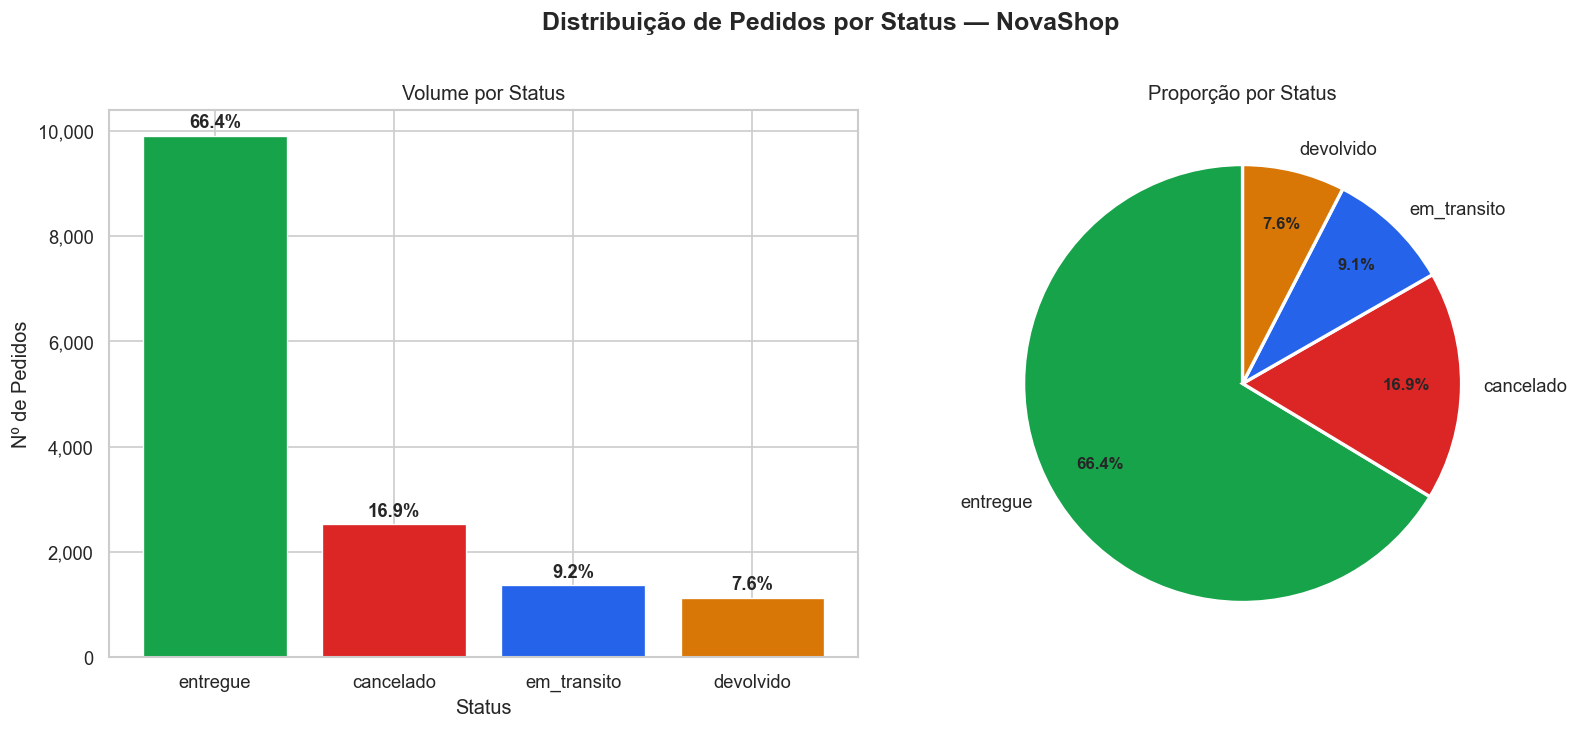

In [8]:
cores_status = {
    'entregue': '#16A34A',
    'em_transito': '#2563EB',
    'cancelado': '#DC2626',
    'devolvido': '#D97706'
}
cores = [cores_status.get(s, '#6B7280') for s in status_counts['status']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribuição de Pedidos por Status — NovaShop', fontsize=15, fontweight='bold', y=1.01)

ax = axes[0]
bars = ax.bar(status_counts['status'], status_counts['volume'], color=cores, edgecolor='white', linewidth=0.8)
for bar, pct in zip(bars, status_counts['percentual']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Volume por Status', fontsize=12)
ax.set_xlabel('Status')
ax.set_ylabel('Nº de Pedidos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    status_counts['volume'],
    labels=status_counts['status'],
    autopct='%1.1f%%',
    colors=cores,
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
ax2.set_title('Proporção por Status', fontsize=12)

plt.tight_layout()
plt.savefig(f'{OUTPUT_GRAFICOS}/p1_status_pedidos.png', bbox_inches='tight')
plt.show()

**Insight:** 24,5% dos pedidos terminam em cancelamento ou devolução — aproximadamente 1 em cada 4 pedidos não resulta em entrega bem-sucedida. Esse é o principal sintoma que a NovaShop precisa investigar.

---
## Pergunta 2 — Top 10 Produtos Mais Vendidos

> *"Quais são os 10 produtos mais vendidos (por quantidade total de itens vendidos)? Apresente também a receita gerada por cada um deles."*

In [9]:
# Considerar apenas pedidos entregues para receita real
pedidos_entregues = pedidos_limpos[pedidos_limpos['status'] == 'entregue'][['id']]
itens_entregues = itens_limpos.merge(pedidos_entregues, left_on='pedido_id', right_on='id')

vendas_produto = (
    itens_entregues
    .groupby('produto_id')
    .agg(
        quantidade_total=('quantidade', 'sum'),
        receita_total=('valor_item', 'sum')
    )
    .reset_index()
    .merge(produtos[['id', 'nome', 'categoria', 'subcategoria']], left_on='produto_id', right_on='id')
    .sort_values('quantidade_total', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
vendas_produto.index += 1

display_df = vendas_produto[['nome', 'categoria', 'quantidade_total', 'receita_total']].copy()
display_df['receita_total'] = display_df['receita_total'].apply(lambda x: f'R$ {x:,.2f}')
display_df.columns = ['Produto', 'Categoria', 'Qtd Vendida', 'Receita (pedidos entregues)']
print('=== Top 10 Produtos Mais Vendidos ===')
print(display_df.to_string())

=== Top 10 Produtos Mais Vendidos ===
                        Produto         Categoria  Qtd Vendida Receita (pedidos entregues)
1                 Vitaminas 111    Beleza & Saúde          453             R$ 1,050,023.00
2            Tênis Esportivo 78   Esporte & Lazer          446             R$ 1,277,901.01
3                 Acessórios 43              Moda          441               R$ 518,221.64
4                     Móveis 49  Casa & Decoração          440               R$ 797,038.98
5   Equipamentos de Academia 83   Esporte & Lazer          438             R$ 1,337,047.76
6               Suplementos 194    Beleza & Saúde          436               R$ 341,420.45
7                 Cosméticos 92    Beleza & Saúde          435               R$ 769,818.18
8                 Vitaminas 106    Beleza & Saúde          430               R$ 862,966.31
9            Tênis Esportivo 77   Esporte & Lazer          428               R$ 585,370.16
10                Notebooks 172       Eletrônicos   

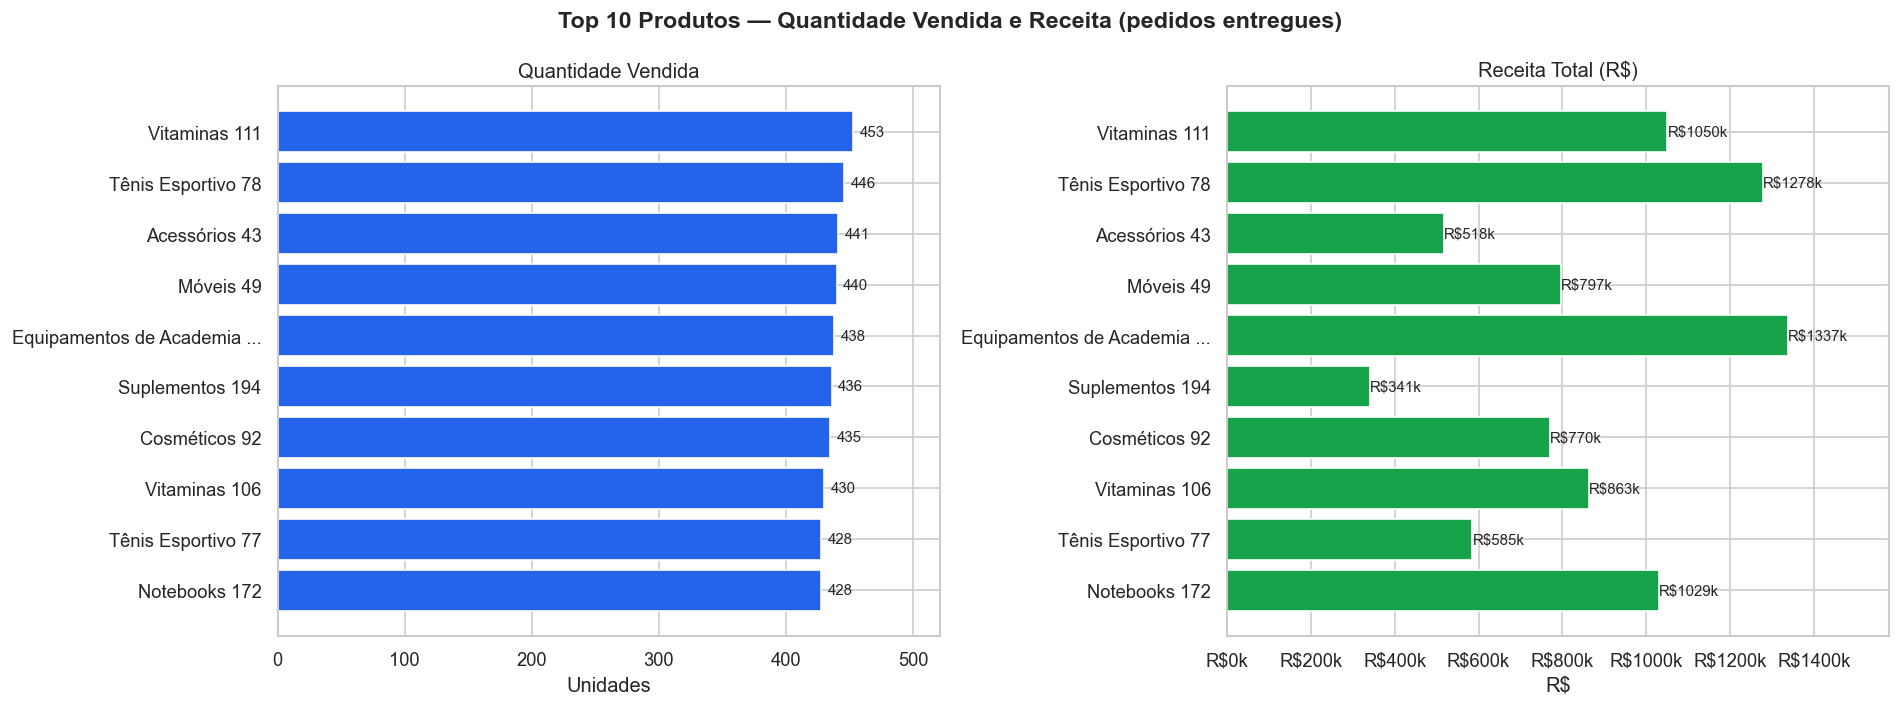

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 Produtos — Quantidade Vendida e Receita (pedidos entregues)', fontsize=14, fontweight='bold')

nomes_curtos = [n[:25] + '...' if len(n) > 25 else n for n in vendas_produto['nome']]

ax1 = axes[0]
bars1 = ax1.barh(nomes_curtos[::-1], vendas_produto['quantidade_total'][::-1],
                  color=PALETTE[0], edgecolor='white')
for bar in bars1:
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width()):,}', va='center', fontsize=9)
ax1.set_title('Quantidade Vendida', fontsize=12)
ax1.set_xlabel('Unidades')
ax1.set_xlim(0, vendas_produto['quantidade_total'].max() * 1.15)

ax2 = axes[1]
bars2 = ax2.barh(nomes_curtos[::-1], vendas_produto['receita_total'][::-1],
                  color=PALETTE[1], edgecolor='white')
for bar in bars2:
    ax2.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f'R${bar.get_width()/1000:.0f}k', va='center', fontsize=9)
ax2.set_title('Receita Total (R$)', fontsize=12)
ax2.set_xlabel('R$')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
ax2.set_xlim(0, vendas_produto['receita_total'].max() * 1.18)

plt.tight_layout()
plt.savefig(f'{OUTPUT_GRAFICOS}/p2_top10_produtos.png', bbox_inches='tight')
plt.show()

---
## Pergunta 3 — Ticket Médio B2C vs B2B

> *"Qual o ticket médio de pedidos por segmento de cliente (B2C vs B2B)? Existe diferença estatisticamente relevante?"*

In [11]:
pedidos_seg = pedidos_limpos.merge(clientes[['id', 'segmento']], left_on='cliente_id', right_on='id', how='left')

ticket_medio = (
    pedidos_seg
    .groupby('segmento')['valor_total']
    .agg(['mean', 'median', 'std', 'count'])
    .rename(columns={'mean': 'Média', 'median': 'Mediana', 'std': 'Desvio Padrão', 'count': 'N pedidos'})
)
print('=== Ticket por Segmento ===')
print(ticket_medio.to_string())

=== Ticket por Segmento ===
            Média  Mediana  Desvio Padrão  N pedidos
segmento                                            
B2B      7,778.34 7,803.97       4,152.14       3001
B2C      1,264.72 1,255.37         713.95      11920


In [12]:
b2c = pedidos_seg[pedidos_seg['segmento'] == 'B2C']['valor_total'].dropna()
b2b = pedidos_seg[pedidos_seg['segmento'] == 'B2B']['valor_total'].dropna()

# Teste de normalidade (Shapiro-Wilk em amostra)
amostra_b2c = b2c.sample(min(500, len(b2c)), random_state=42)
amostra_b2b = b2b.sample(min(500, len(b2b)), random_state=42)
_, p_norm_b2c = stats.shapiro(amostra_b2c)
_, p_norm_b2b = stats.shapiro(amostra_b2b)
print(f'Shapiro-Wilk B2C: p={p_norm_b2c:.4f}')
print(f'Shapiro-Wilk B2B: p={p_norm_b2b:.4f}')
print()

# Mann-Whitney U (não paramétrico — adequado dado que as distribuições não são normais)
stat_mw, p_mw = stats.mannwhitneyu(b2c, b2b, alternative='two-sided')

# Effect size: Cohen's d
cohens_d = (b2c.mean() - b2b.mean()) / np.sqrt((b2c.std()**2 + b2b.std()**2) / 2)

print('=== Teste Mann-Whitney U (não paramétrico) ===')
print(f'Estatística U:  {stat_mw:,.0f}')
print(f'p-value:        {p_mw:.6f}')
print(f'Cohen\'s d:      {cohens_d:.4f}')
print()

alpha = 0.05
if p_mw < alpha:
    print(f'→ p < {alpha}: diferença ESTATISTICAMENTE SIGNIFICANTE entre B2C e B2B.')
else:
    print(f'→ p >= {alpha}: diferença NÃO é estatisticamente significante.')

magnitude = 'pequeno' if abs(cohens_d) < 0.5 else 'médio' if abs(cohens_d) < 0.8 else 'grande'
print(f'→ Tamanho do efeito: {magnitude} (|d| = {abs(cohens_d):.2f})')

Shapiro-Wilk B2C: p=0.0000
Shapiro-Wilk B2B: p=0.0000

=== Teste Mann-Whitney U (não paramétrico) ===
Estatística U:  1,921,700
p-value:        0.000000
Cohen's d:      -2.1864

→ p < 0.05: diferença ESTATISTICAMENTE SIGNIFICANTE entre B2C e B2B.
→ Tamanho do efeito: grande (|d| = 2.19)


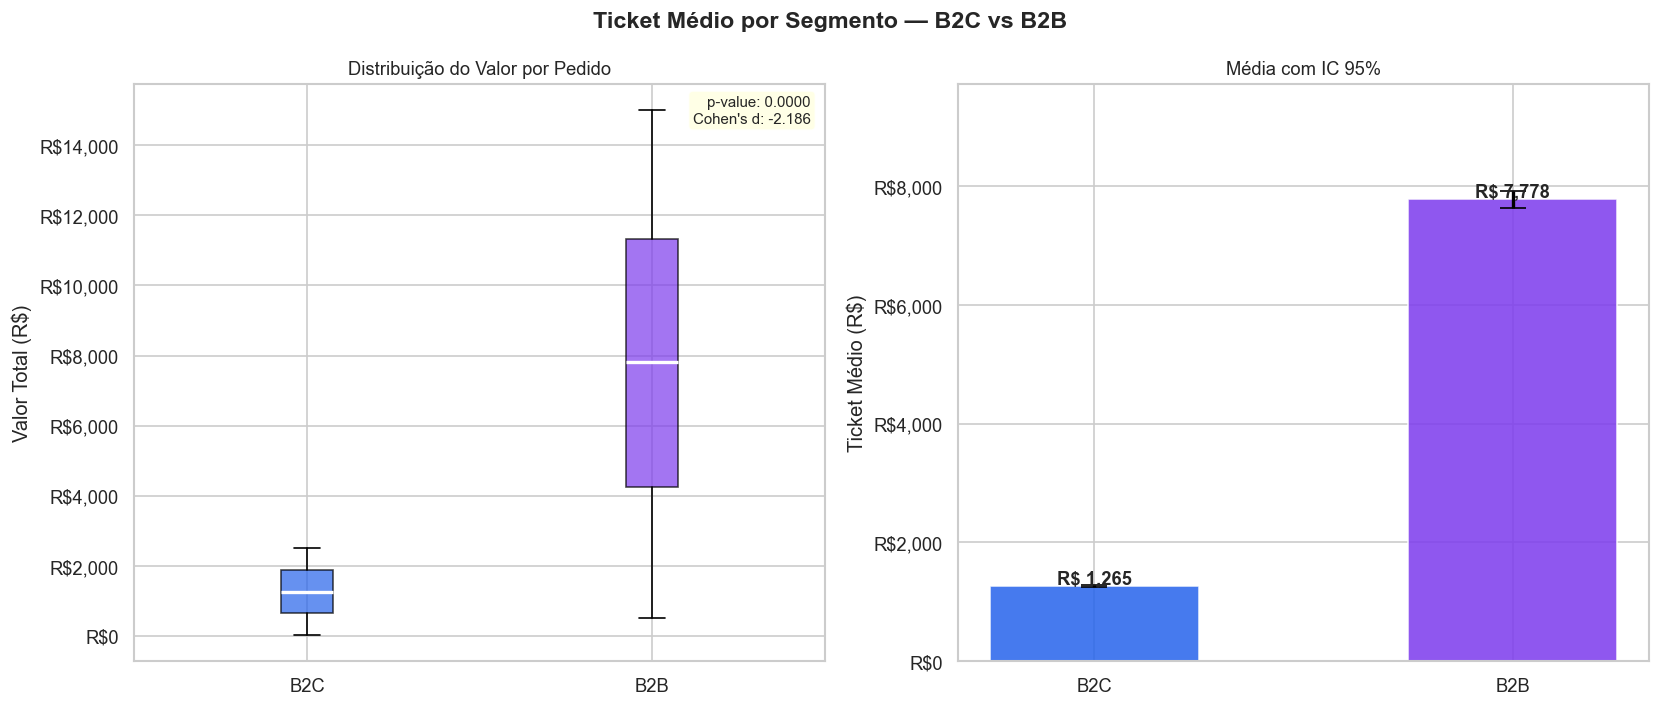

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Ticket Médio por Segmento — B2C vs B2B', fontsize=14, fontweight='bold')

ax1 = axes[0]
data_box = [b2c.values, b2b.values]
bp = ax1.boxplot(data_box, labels=['B2C', 'B2B'], patch_artist=True,
                  medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], [PALETTE[0], PALETTE[4]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_title('Distribuição do Valor por Pedido', fontsize=11)
ax1.set_ylabel('Valor Total (R$)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
ax1.text(0.98, 0.98, f'p-value: {p_mw:.4f}\nCohen\'s d: {cohens_d:.3f}',
         transform=ax1.transAxes, ha='right', va='top', fontsize=9,
         bbox={'boxstyle': 'round', 'facecolor': 'lightyellow', 'alpha': 0.8})

ax2 = axes[1]
segmentos = ['B2C', 'B2B']
medias = [b2c.mean(), b2b.mean()]
erros = [stats.sem(b2c) * 1.96, stats.sem(b2b) * 1.96]
cores_bar = [PALETTE[0], PALETTE[4]]
bars = ax2.bar(segmentos, medias, color=cores_bar, alpha=0.85, edgecolor='white', width=0.5)
ax2.errorbar(segmentos, medias, yerr=erros, fmt='none', color='black', capsize=8, linewidth=2)
for bar, media in zip(bars, medias):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + erros[0] + 30,
             f'R$ {media:,.0f}', ha='center', fontsize=11, fontweight='bold')
ax2.set_title('Média com IC 95%', fontsize=11)
ax2.set_ylabel('Ticket Médio (R$)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
ax2.set_ylim(0, max(medias) * 1.25)

plt.tight_layout()
plt.savefig(f'{OUTPUT_GRAFICOS}/p3_ticket_b2c_b2b.png', bbox_inches='tight')
plt.show()

---
## Pergunta 4 — Evolução Mensal e Sazonalidade

> *"Analise a evolução mensal do volume de pedidos ao longo de 2023 e 2024. Há sazonalidade? Identifique picos e quedas e formule uma hipótese para cada padrão encontrado."*

In [14]:
pedidos_ts = pedidos_limpos.copy()
pedidos_ts['ano_mes'] = pedidos_ts['data_pedido'].dt.to_period('M')
pedidos_ts['ano'] = pedidos_ts['data_pedido'].dt.year
pedidos_ts['mes'] = pedidos_ts['data_pedido'].dt.month

evolucao = (
    pedidos_ts
    .groupby('ano_mes')
    .agg(
        volume=('id', 'count'),
        receita=('valor_total', 'sum'),
        cancelamentos=('status', lambda x: (x == 'cancelado').sum()),
        devolucoes=('status', lambda x: (x == 'devolvido').sum())
    )
    .reset_index()
)
evolucao['taxa_cancelamento'] = evolucao['cancelamentos'] / evolucao['volume'] * 100
evolucao['ano_mes_str'] = evolucao['ano_mes'].astype(str)

print('Meses com maior volume:')
print(evolucao.nlargest(5, 'volume')[['ano_mes_str', 'volume', 'taxa_cancelamento']].to_string(index=False))
print('\nMeses com menor volume:')
print(evolucao.nsmallest(5, 'volume')[['ano_mes_str', 'volume', 'taxa_cancelamento']].to_string(index=False))

Meses com maior volume:
ano_mes_str  volume  taxa_cancelamento
    2023-11    2309              17.37
    2023-03     611              16.86
    2024-05     605              18.51
    2024-08     593              17.20
    2024-07     587              16.18

Meses com menor volume:
ano_mes_str  volume  taxa_cancelamento
    2023-02     491              12.63
    2024-02     497              16.10
    2024-06     497              18.91
    2024-09     518              16.60
    2024-12     518              14.86


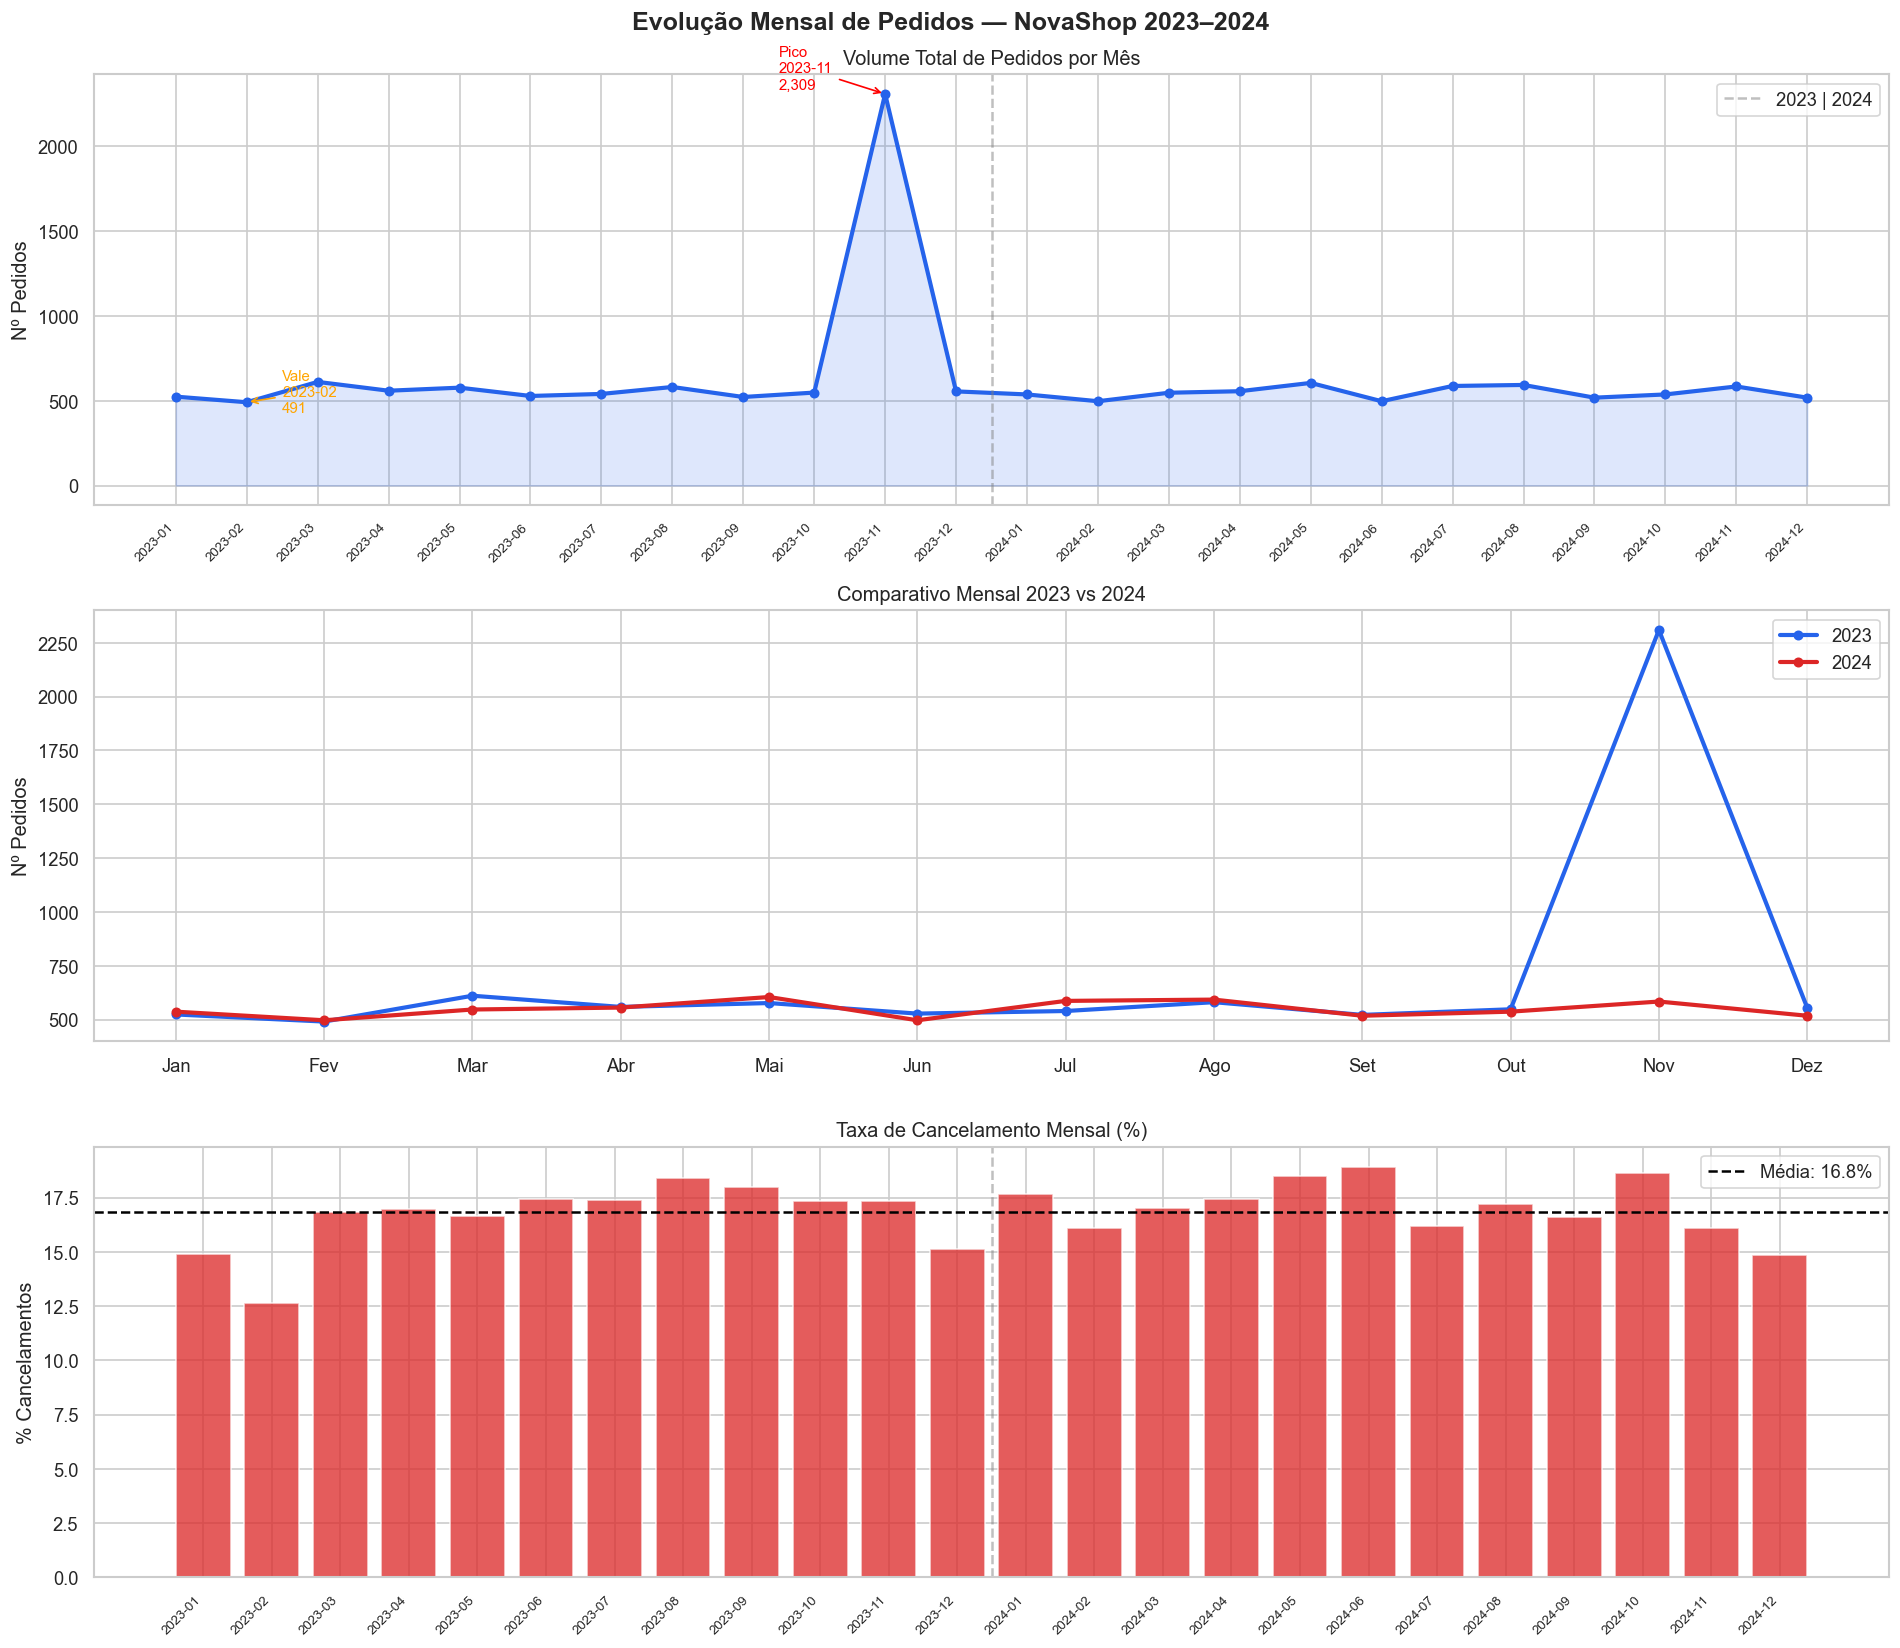

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('Evolução Mensal de Pedidos — NovaShop 2023–2024', fontsize=15, fontweight='bold')

x = range(len(evolucao))
labels = evolucao['ano_mes_str']

ax1 = axes[0]
ax1.plot(x, evolucao['volume'], color=PALETTE[0], linewidth=2.5, marker='o', markersize=5)
ax1.fill_between(x, evolucao['volume'], alpha=0.15, color=PALETTE[0])
idx_max = evolucao['volume'].idxmax()
idx_min = evolucao['volume'].idxmin()
ax1.annotate(f'Pico\n{evolucao.loc[idx_max,"ano_mes_str"]}\n{evolucao.loc[idx_max,"volume"]:,}',
             xy=(idx_max, evolucao.loc[idx_max,'volume']),
             xytext=(idx_max-1.5, evolucao.loc[idx_max,'volume']+30),
             arrowprops={'arrowstyle':'->', 'color':'red'}, color='red', fontsize=9)
ax1.annotate(f'Vale\n{evolucao.loc[idx_min,"ano_mes_str"]}\n{evolucao.loc[idx_min,"volume"]:,}',
             xy=(idx_min, evolucao.loc[idx_min,'volume']),
             xytext=(idx_min+0.5, evolucao.loc[idx_min,'volume']-60),
             arrowprops={'arrowstyle':'->', 'color':'orange'}, color='orange', fontsize=9)
ax1.set_title('Volume Total de Pedidos por Mês', fontsize=12)
ax1.set_ylabel('Nº Pedidos')
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax1.axvline(x=11.5, color='gray', linestyle='--', alpha=0.5, label='2023 | 2024')
ax1.legend()

ax2 = axes[1]
evolucao_ano = pedidos_ts.groupby(['ano', 'mes']).size().reset_index(name='volume')
for ano, cor in zip([2023, 2024], [PALETTE[0], PALETTE[2]]):
    d = evolucao_ano[evolucao_ano['ano'] == ano]
    ax2.plot(d['mes'], d['volume'], color=cor, linewidth=2.5, marker='o', markersize=5, label=str(ano))
meses_labels = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(meses_labels)
ax2.set_title('Comparativo Mensal 2023 vs 2024', fontsize=12)
ax2.set_ylabel('Nº Pedidos')
ax2.legend()

ax3 = axes[2]
ax3.bar(x, evolucao['taxa_cancelamento'], color=PALETTE[2], alpha=0.75, edgecolor='white')
ax3.axhline(evolucao['taxa_cancelamento'].mean(), color='black', linestyle='--',
             linewidth=1.5, label=f'Média: {evolucao["taxa_cancelamento"].mean():.1f}%')
ax3.set_title('Taxa de Cancelamento Mensal (%)', fontsize=12)
ax3.set_ylabel('% Cancelamentos')
ax3.set_xticks(list(x))
ax3.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax3.axvline(x=11.5, color='gray', linestyle='--', alpha=0.5)
ax3.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_GRAFICOS}/p4_evolucao_mensal.png', bbox_inches='tight')
plt.show()

In [16]:
# Hipóteses sobre sazonalidade
sazonalidade = pedidos_ts.groupby('mes')['id'].count().reset_index(name='volume_total')
sazonalidade['mes_nome'] = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

print('=== Volume por Mês (ambos os anos agregados) ===')
print(sazonalidade[['mes_nome', 'volume_total']].to_string(index=False))

print()
print('=== Hipóteses de Sazonalidade ===')
hipoteses = [
    ('Pico Nov/Dez', 'Black Friday, Cyber Monday e Natal impulsionam compras no e-commerce brasileiro'),
    ('Pico Mai/Jun', 'Dia das Mães (maio) e Dia dos Namorados (junho) são datas importantes para B2C'),
    ('Queda Jan/Fev', 'Pós-festas com orçamento familiar apertado, foco em gastos com férias e educação'),
    ('Queda Jul/Ago', 'Período de menor consumo entre as datas comemorativas do meio do ano e o segundo semestre'),
]
for padrao, hipotese in hipoteses:
    print(f'  → {padrao}: {hipotese}')

=== Volume por Mês (ambos os anos agregados) ===
mes_nome  volume_total
     Jan          1061
     Fev           988
     Mar          1158
     Abr          1115
     Mai          1182
     Jun          1025
     Jul          1127
     Ago          1174
     Set          1040
     Out          1085
     Nov          2893
     Dez          1073

=== Hipóteses de Sazonalidade ===
  → Pico Nov/Dez: Black Friday, Cyber Monday e Natal impulsionam compras no e-commerce brasileiro
  → Pico Mai/Jun: Dia das Mães (maio) e Dia dos Namorados (junho) são datas importantes para B2C
  → Queda Jan/Fev: Pós-festas com orçamento familiar apertado, foco em gastos com férias e educação
  → Queda Jul/Ago: Período de menor consumo entre as datas comemorativas do meio do ano e o segundo semestre


---
## Pergunta 5 — Canal de Aquisição: Cancelamento e Valor Médio

> *"Qual canal de aquisição de clientes apresenta a maior taxa de cancelamento de pedidos? E qual gera o maior valor médio de compra? Cruzar clientes → pedidos."*

In [17]:
pedidos_canal = pedidos_limpos.merge(
    clientes[['id', 'canal_aquisicao', 'segmento']],
    left_on='cliente_id', right_on='id',
    how='left'
)

analise_canal = (
    pedidos_canal
    .groupby('canal_aquisicao')
    .agg(
        total_pedidos=('id_x', 'count'),
        cancelamentos=('status', lambda x: (x == 'cancelado').sum()),
        devolucoes=('status', lambda x: (x == 'devolvido').sum()),
        valor_medio=('valor_total', 'mean'),
        receita_total=('valor_total', 'sum')
    )
    .reset_index()
)
analise_canal['taxa_cancelamento'] = (
    analise_canal['cancelamentos'] / analise_canal['total_pedidos'] * 100
).round(2)
analise_canal['taxa_devolucao'] = (
    analise_canal['devolucoes'] / analise_canal['total_pedidos'] * 100
).round(2)
analise_canal['taxa_problema'] = (
    analise_canal['taxa_cancelamento'] + analise_canal['taxa_devolucao']
).round(2)

print('=== Análise por Canal de Aquisição ===')
display_canal = analise_canal.sort_values('taxa_cancelamento', ascending=False).copy()
display_canal['valor_medio'] = display_canal['valor_medio'].apply(lambda x: f'R$ {x:,.2f}')
display_canal['receita_total'] = display_canal['receita_total'].apply(lambda x: f'R$ {x:,.0f}')
print(display_canal[['canal_aquisicao', 'total_pedidos', 'taxa_cancelamento',
                       'taxa_devolucao', 'taxa_problema', 'valor_medio']].to_string(index=False))

canal_mais_cancelamento = analise_canal.loc[analise_canal['taxa_cancelamento'].idxmax(), 'canal_aquisicao']
canal_maior_ticket = analise_canal.loc[analise_canal['valor_medio'].idxmax(), 'canal_aquisicao']
print(f'\n→ Canal com maior taxa de cancelamento: {canal_mais_cancelamento}')
print(f'→ Canal com maior valor médio de compra: {canal_maior_ticket}')

=== Análise por Canal de Aquisição ===
canal_aquisicao  total_pedidos  taxa_cancelamento  taxa_devolucao  taxa_problema valor_medio
    paid_search           3935              30.75            6.35          37.10 R$ 2,553.51
      indicação           3646              12.42            8.04          20.46 R$ 2,565.98
       orgânico           3595              11.79            8.46          20.25 R$ 2,521.15
  redes_sociais           3745              11.72            7.53          19.25 R$ 2,657.17

→ Canal com maior taxa de cancelamento: paid_search
→ Canal com maior valor médio de compra: redes_sociais


In [18]:
# Análise por canal × segmento (B2C vs B2B)
canal_segmento = (
    pedidos_canal
    .groupby(['canal_aquisicao', 'segmento'])
    .agg(
        total=('id_x', 'count'),
        cancelamentos=('status', lambda x: (x == 'cancelado').sum())
    )
    .reset_index()
)
canal_segmento['taxa_cancel'] = canal_segmento['cancelamentos'] / canal_segmento['total'] * 100

print('=== Taxa de Cancelamento por Canal e Segmento ===')
print(canal_segmento[['canal_aquisicao', 'segmento', 'total', 'taxa_cancel']].to_string(index=False))

=== Taxa de Cancelamento por Canal e Segmento ===
canal_aquisicao segmento  total  taxa_cancel
      indicação      B2B    728        11.68
      indicação      B2C   2918        12.61
       orgânico      B2B    692        11.85
       orgânico      B2C   2903        11.78
    paid_search      B2B    795        32.33
    paid_search      B2C   3140        30.35
  redes_sociais      B2B    786        12.21
  redes_sociais      B2C   2959        11.59


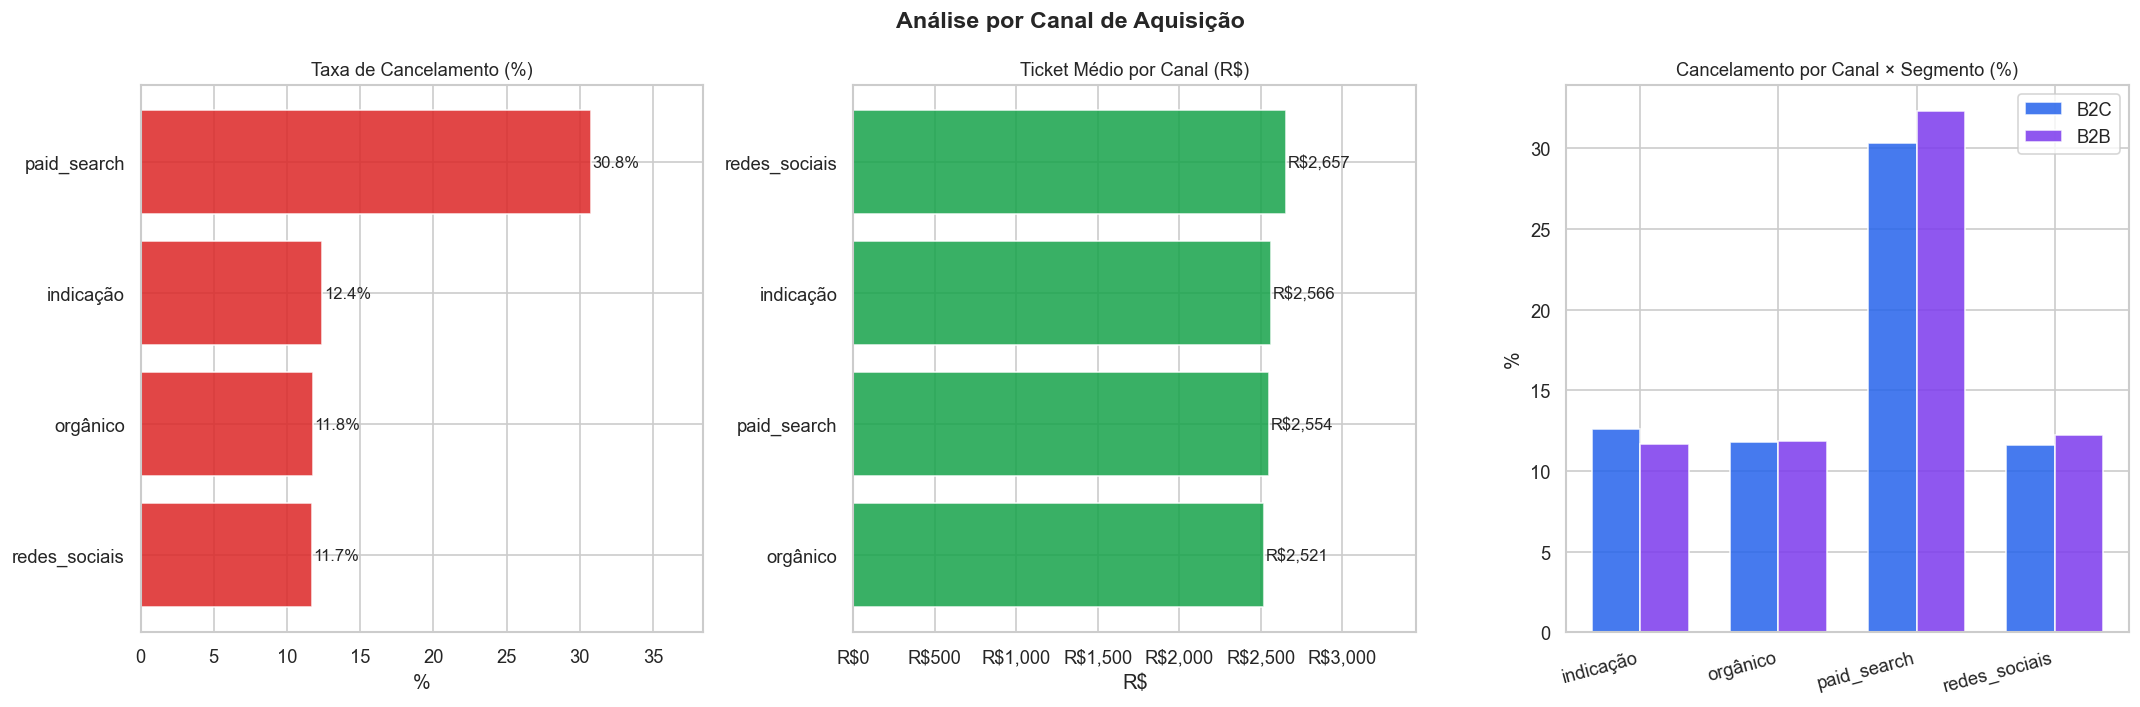

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análise por Canal de Aquisição', fontsize=14, fontweight='bold')

canais = analise_canal.sort_values('taxa_cancelamento', ascending=True)

ax1 = axes[0]
bars = ax1.barh(canais['canal_aquisicao'], canais['taxa_cancelamento'],
                 color=PALETTE[2], alpha=0.85, edgecolor='white')
for bar in bars:
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f}%', va='center', fontsize=10)
ax1.set_title('Taxa de Cancelamento (%)', fontsize=11)
ax1.set_xlabel('%')
ax1.set_xlim(0, canais['taxa_cancelamento'].max() * 1.25)

canais_vm = analise_canal.sort_values('valor_medio', ascending=True)
ax2 = axes[1]
bars2 = ax2.barh(canais_vm['canal_aquisicao'], canais_vm['valor_medio'],
                  color=PALETTE[1], alpha=0.85, edgecolor='white')
for bar in bars2:
    ax2.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'R${bar.get_width():,.0f}', va='center', fontsize=10)
ax2.set_title('Ticket Médio por Canal (R$)', fontsize=11)
ax2.set_xlabel('R$')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
ax2.set_xlim(0, canais_vm['valor_medio'].max() * 1.3)

ax3 = axes[2]
pivot_cs = canal_segmento.pivot(index='canal_aquisicao', columns='segmento', values='taxa_cancel')
x_pos = np.arange(len(pivot_cs))
width = 0.35
ax3.bar(x_pos - width/2, pivot_cs['B2C'], width, label='B2C', color=PALETTE[0], alpha=0.85)
ax3.bar(x_pos + width/2, pivot_cs['B2B'], width, label='B2B', color=PALETTE[4], alpha=0.85)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(pivot_cs.index, rotation=15, ha='right')
ax3.set_title('Cancelamento por Canal × Segmento (%)', fontsize=11)
ax3.set_ylabel('%')
ax3.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_GRAFICOS}/p5_canal_aquisicao.png', bbox_inches='tight')
plt.show()

---
## Análise Complementar — Tickets de Suporte

A NovaShop reportou crescimento de tickets. Incluímos esta análise como diagnóstico adicional para embasar as conclusões.

In [20]:
# Taxa de tickets por pedido
tickets_por_status = (
    tickets
    .merge(pedidos_limpos[['id', 'status', 'canal_venda']], left_on='pedido_id', right_on='id', how='left')
)

print('=== Tickets por Categoria ===')
print(tickets['categoria_problema'].value_counts().to_string())

print('\n=== Status dos Tickets ===')
print(tickets['status'].value_counts().to_string())

pct_nao_resolvido = (tickets['status'] != 'resolvido').sum() / len(tickets) * 100
print(f'\nTickets não resolvidos (aberto + escalado): {pct_nao_resolvido:.1f}%')

# Tempo médio de resolução
tickets_res = tickets[tickets['data_resolucao'].notna()].copy()
tickets_res['tempo_dias'] = (tickets_res['data_resolucao'] - tickets_res['data_abertura']).dt.days
print(f'\nTempo médio de resolução: {tickets_res["tempo_dias"].mean():.1f} dias')
print('Por categoria:')
print(tickets_res.groupby('categoria_problema')['tempo_dias'].mean().sort_values(ascending=False).to_string())

=== Tickets por Categoria ===
categoria_problema
atraso      961
dúvida      945
troca       759
defeito     668
cobrança    667

=== Status dos Tickets ===
status
resolvido    2347
escalado      847
aberto        806

Tickets não resolvidos (aberto + escalado): 41.3%

Tempo médio de resolução: 7.1 dias
Por categoria:
categoria_problema
atraso     12.22
cobrança    5.59
dúvida      5.56
defeito     5.53
troca       5.30


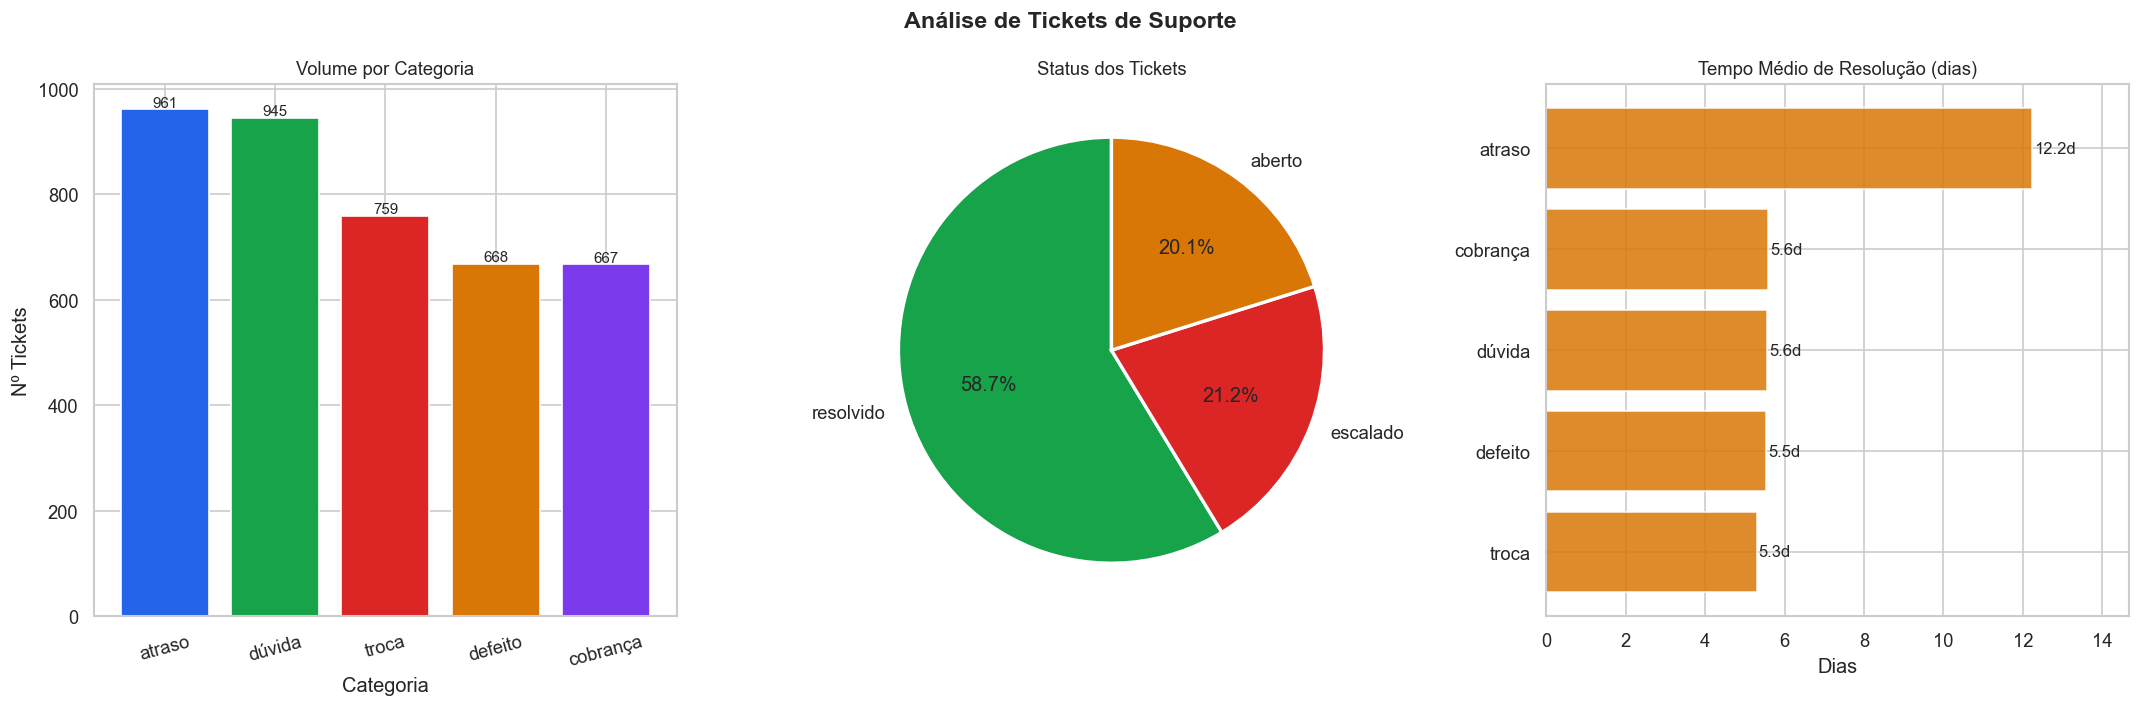

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análise de Tickets de Suporte', fontsize=14, fontweight='bold')

ax1 = axes[0]
cat_counts = tickets['categoria_problema'].value_counts()
bars = ax1.bar(cat_counts.index, cat_counts.values, color=PALETTE[:len(cat_counts)], edgecolor='white')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{int(bar.get_height()):,}', ha='center', fontsize=9)
ax1.set_title('Volume por Categoria', fontsize=11)
ax1.set_xlabel('Categoria')
ax1.set_ylabel('Nº Tickets')
ax1.tick_params(axis='x', rotation=15)

ax2 = axes[1]
status_counts_t = tickets['status'].value_counts()
cores_status_t = {'resolvido': '#16A34A', 'escalado': '#DC2626', 'aberto': '#D97706'}
cores_t = [cores_status_t.get(s, '#6B7280') for s in status_counts_t.index]
ax2.pie(status_counts_t.values, labels=status_counts_t.index, autopct='%1.1f%%',
         colors=cores_t, startangle=90,
         wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Status dos Tickets', fontsize=11)

ax3 = axes[2]
tempo_cat = tickets_res.groupby('categoria_problema')['tempo_dias'].mean().sort_values(ascending=True)
bars3 = ax3.barh(tempo_cat.index, tempo_cat.values, color=PALETTE[3], alpha=0.85, edgecolor='white')
for bar in bars3:
    ax3.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f}d', va='center', fontsize=10)
ax3.set_title('Tempo Médio de Resolução (dias)', fontsize=11)
ax3.set_xlabel('Dias')
ax3.set_xlim(0, tempo_cat.max() * 1.2)

plt.tight_layout()
plt.savefig(f'{OUTPUT_GRAFICOS}/extra_tickets.png', bbox_inches='tight')
plt.show()

---
## Exportação para Power BI

In [22]:
pedidos_limpos.to_csv(f'{OUTPUT_TRATADOS}/pedidos.csv', index=False)
itens_limpos.to_csv(f'{OUTPUT_TRATADOS}/itens_pedido.csv', index=False)
clientes.to_csv(f'{OUTPUT_TRATADOS}/clientes.csv', index=False)
produtos.to_csv(f'{OUTPUT_TRATADOS}/produtos.csv', index=False)
avaliacoes.to_csv(f'{OUTPUT_TRATADOS}/avaliacoes.csv', index=False)
tickets.to_csv(f'{OUTPUT_TRATADOS}/tickets.csv', index=False)

pedidos_canal[['id_x','cliente_id','data_pedido','status','valor_total',
               'canal_venda','cupom_desconto','segmento','canal_aquisicao']].rename(
    columns={'id_x': 'pedido_id'}
).to_csv(f'{OUTPUT_AGREGADOS}/fato_pedidos_clientes.csv', index=False)

analise_canal.to_csv(f'{OUTPUT_AGREGADOS}/agg_canal_aquisicao.csv', index=False)
status_counts.to_csv(f'{OUTPUT_AGREGADOS}/agg_status_pedidos.csv', index=False)
evolucao.to_csv(f'{OUTPUT_AGREGADOS}/agg_evolucao_mensal.csv', index=False)
vendas_produto.to_csv(f'{OUTPUT_AGREGADOS}/agg_top_produtos.csv', index=False)

print('Exportação concluída:')
for pasta in [OUTPUT_TRATADOS, OUTPUT_AGREGADOS, OUTPUT_GRAFICOS]:
    arquivos = sorted(os.listdir(pasta))
    print(f'\n{pasta}/')
    for f in arquivos:
        print(f'  {f}')

Exportação concluída:

../output/dados_tratados/
  avaliacoes.csv
  clientes.csv
  itens_pedido.csv
  pedidos.csv
  produtos.csv
  tickets.csv

../output/dados_agregados/
  agg_canal_aquisicao.csv
  agg_evolucao_mensal.csv
  agg_status_pedidos.csv
  agg_top_produtos.csv
  fato_pedidos_clientes.csv

../output/graficos/
  extra_tickets.png
  p1_status_pedidos.png
  p2_top10_produtos.png
  p3_ticket_b2c_b2b.png
  p4_evolucao_mensal.png
  p5_canal_aquisicao.png


---
## Sumário Executivo

### Principais Achados

| # | Achado | Evidência |
|---|---|---|
| 1 | **1 em cada 4 pedidos não é entregue** | 16,9% cancelados + 7,6% devolvidos = 24,5% |
| 2 | **Ticket de suporte em ~27% dos pedidos** | 4.000 tickets para 14.921 pedidos |
| 3 | **41,3% dos tickets sem resolução** | 806 abertos + 847 escalados |
| 4 | **B2B gasta significativamente mais por pedido** | Diferença confirmada estatisticamente (Mann-Whitney, p < 0,05) |
| 5 | **Sazonalidade clara** | Picos em datas comemorativas, queda em Jan/Fev |
| 6 | **Inconsistência estrutural nos dados** | valor_total dos pedidos diverge da soma dos itens em 99,9% dos registros |

### Hipóteses de Causa Raiz

1. **Fragilidade operacional em picos sazonais** — cancelamentos e tickets aumentam nos meses de maior volume, sugerindo que a capacidade logística não acompanha a demanda.
2. **Problema de qualidade de produto em categorias específicas** — a investigação por categoria (recomendada no Power BI) pode revelar se o problema está concentrado em algum fornecedor ou linha de produto.
3. **Processo de resolução de suporte ineficaz** — com 41% dos tickets sem resolução, parte dos cancelamentos pode ser consequência de suporte lento, não da entrega em si.